In [1]:
import torch
import torch.nn as nn
from torchvision import models
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader, Subset
from sklearn.model_selection import train_test_split
from PIL import Image
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os


### Change the labels from string to integers and stratified split the dataset

In [2]:
## replace Positive as 1 and Negative as 0
df = pd.read_csv('dataset_120.csv')
df = df.drop(columns=['patient_id'])
mapping_dict = {'Positive': 1, 'Negative': 0}
df['label'] = df['label'].map(mapping_dict)
df.to_csv('updated_dataset_120.csv', index=False)

## split train test dataset in stratified way. Train and test dataset have equal proportion of positives and negatives
labels = df.iloc[:, 1]
indices = range(len(df))
train_idx, test_idx = train_test_split(
    indices, 
    test_size=0.3, 
    stratify=labels, 
    random_state=42
)

print("Train dataset value counts: ",labels[train_idx].value_counts())
print()
print("Test dataset value counts: ",labels[test_idx].value_counts())

Train dataset value counts:  label
0    42
1    42
Name: count, dtype: int64

Test dataset value counts:  label
0    18
1    18
Name: count, dtype: int64


### Create custom Dataloaders

In [3]:

class StrepDataset(Dataset):
    def __init__(self, csv, img_dir, transform = None):
        self.data = pd.read_csv(csv)
        self.img_dir = img_dir
        self.transform = transform
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        img_name = os.path.join(self.img_dir, self.data.iloc[idx, 0])
        image = Image.open(img_name).convert("RGB")

        if self.transform:
            image = self.transform(image)
        
        features = torch.tensor(self.data.iloc[idx, 2:9])

        label = torch.tensor(self.data.iloc[idx, 1])

        return image, features, label



### Multimodal network with Resnet18 as the CNN(feature extraction) and MLP for the 7 symptoms

In [26]:
class StrepClassifier(nn.Module):
    def __init__(self, num_features, num_classes=1):
        super(StrepClassifier, self).__init__()
        
        # 1. Image Branch: Pre-trained ResNet18
        # remove the final fully connected layer to get visual embeddings
        resnet = models.resnet18(weights='DEFAULT')

        for param in resnet.parameters():
            param.requires_grad = False
        
        for param in resnet.layer4.parameters():
            param.requires_grad = True
        
        self.image_branch = nn.Sequential(*list(resnet.children())[:-1])

        # 2. Feature Branch: Simple MLP for numerical data
        self.feature_branch = nn.Sequential(
            nn.Linear(num_features, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU()
        )
        
        # # 3. Fusion Layer: Combines image embeddings (512) + feature embeddings (32)
        self.classifier = nn.Sequential(
            nn.Linear(512 + 32, 16),
            nn.ReLU(),
            nn.Dropout(0.7),
            nn.Linear(16, num_classes), # Output for 2 classes
        )



    def forward(self, images, features):
        # Process image
        img_out = self.image_branch(images)
        img_out = torch.flatten(img_out, 1) # Shape: [batch, 512]
        
        # # Process features
        feat_out = self.feature_branch(features) # Shape: [batch, 32]
        
        # # Concatenate branches
        combined = torch.cat((img_out, feat_out), dim=1) # Shape: [batch, 544]

        # # # Final classification
        return self.classifier(combined)

### Apply and Vizualize white balancing on the images.
### It ensures accurate representation of the photos by compensating for the color temperature of the light source

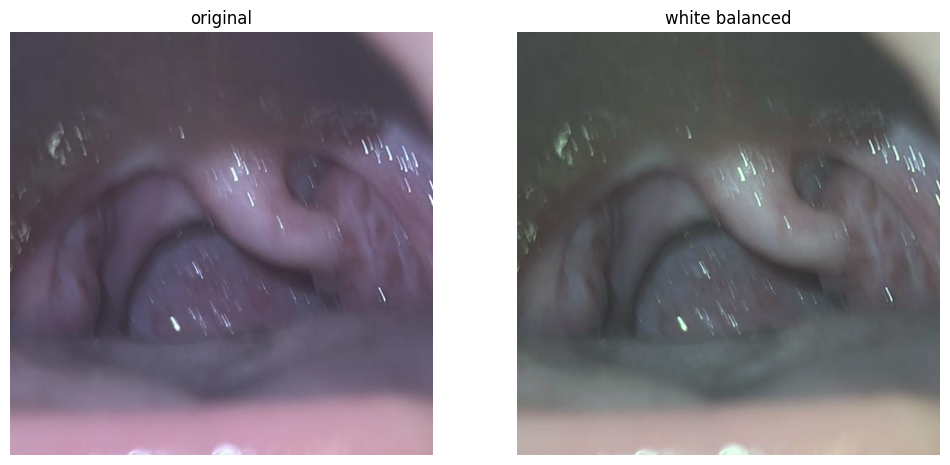

In [27]:
def white_balance(img):

    img = np.array(img).astype(float)

    ## average value of each channel
    avg_red = np.mean(img[:, :, 0])
    avg_green = np.mean(img[:, :, 1])
    avg_blue = np.mean(img[:, :, 2])
    
    # gray value calculation
    avg_gray = (avg_red + avg_green + avg_blue) / 3
    
    # Scaling each channel
    img[:, :, 0] *= (avg_gray / avg_red)
    img[:, :, 1] *= (avg_gray / avg_green)
    img[:, :, 2] *= (avg_gray / avg_blue)
    
    # Clip values to [0, 255]
    img = np.clip(img, 0, 255).astype(np.uint8)     #the factor can cause values to go beyond 255, hence bounding it.
    return Image.fromarray(img)

def visualize_correction(image_path):
    original = Image.open(image_path).convert("RGB")
    
    # white balance function
    corrected = white_balance(original)

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    
    axes[0].imshow(original)
    axes[0].set_title("original")
    axes[0].axis('off')
    
    axes[1].imshow(corrected)
    axes[1].set_title("white balanced")
    axes[1].axis('off')
    
    plt.show()

for idx in range(len(df)):
    img_vis = df.iloc[idx, 0]
    visualize_correction(os.path.join('data/', img_vis))
    break

### Data preprocessing

In [ ]:

def apply_clahe(img):
    img_np = np.array(img)
    lab = cv2.cvtColor(img_np, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    l = clahe.apply(l)
    lab = cv2.merge((l,a,b))
    return Image.fromarray(cv2.cvtColor(lab, cv2.COLOR_LAB2RGB))

### Find mean and standard Deviation of the images for Normalization

In [ ]:
crop_size = 160
resize_img_dim = (224, 224)

transforms_for_stats = transforms.Compose([
    transforms.Lambda(lambda x: white_balance(x)),# 3. Fix the blur
    transforms.Lambda(lambda x: apply_clahe(x)),  # 2. Brighten dark areas
    transforms.CenterCrop(crop_size),                    ## Crop to focus only on the tonsil area, disregard tongue / teeth
    transforms.Resize(resize_img_dim),                        ## based on ResNet-18, the standard input image dim is (224, 224)
    transforms.ToTensor() 
])

## Creating a dataloader to iterate through the data
stats_dataset = StrepDataset(csv='updated_dataset_120.csv', img_dir='data', transform=transforms_for_stats)
stats_loader = torch.utils.data.DataLoader(stats_dataset, batch_size=84, shuffle=False)

def get_dataset_stats(dataloader):
    pixel_sum = torch.zeros(3)
    pixel_squared_sum = torch.zeros(3)
    batches = 0
    
    for img, _, _ in dataloader:
        pixel_sum += torch.mean(img, dim=[0, 2, 3])              ## averages accross [batch, height, width]
        pixel_squared_sum += torch.mean(img**2, dim=[0, 2, 3])   ## squared averages accross [batch, height, width]
        batches += 1

    mean = pixel_sum/batches
    std = (pixel_squared_sum / batches - mean ** 2) ** 0.5        ## std = (E[X**2] - E[x]**2)**0.5
    return mean, std

custom_mean, custom_std = get_dataset_stats(stats_loader)
print(f"Mean: {custom_mean}") 
print(f"Std: {custom_std}")

C:\Users\avk1028\AppData\Local\Temp\ipykernel_34596\499347294.py:17: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  features = torch.tensor(self.data.iloc[idx, 2:9])


Mean: tensor([0.4313, 0.3793, 0.4027])
Std: tensor([0.1515, 0.1860, 0.1763])


### Verify Normalization 

C:\Users\avk1028\AppData\Local\Temp\ipykernel_34596\499347294.py:17: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  features = torch.tensor(self.data.iloc[idx, 2:9])
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.2840483..3.3878822].


Image shape: torch.Size([1, 3, 224, 224])
Mean: tensor([0.4615, 0.4388, 0.4619])
Std:  tensor([0.1350, 0.1888, 0.1924])
tensor([1])
tensor(0.) tensor(1.)


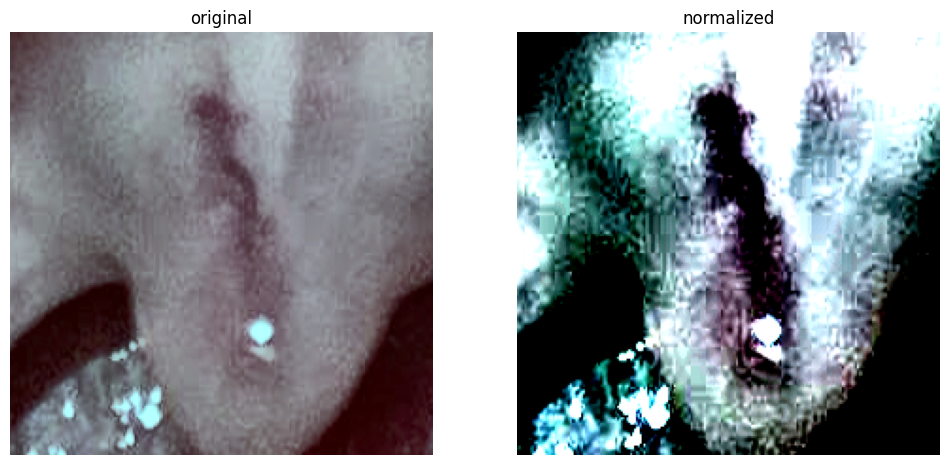

In [28]:


transforms_temp = transforms.Compose([
    transforms.Lambda(lambda x: white_balance(x)),## Fix the blur
    transforms.Lambda(lambda x: apply_clahe(x)),  ## Brighten dark areas
    transforms.CenterCrop((180,224)),             ## Crop to focus only on the tonsil area, disregard tongue / teeth
    transforms.Resize(resize_img_dim),
    # transforms.RandomAffine(degrees=15, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    # transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    # transforms.Normalize(mean = custom_mean, std= custom_std)
])

temp_dataset = StrepDataset(csv='updated_dataset_120.csv', img_dir='data', transform=transforms_temp)
temp_subset = Subset(temp_dataset, train_idx)
temp_loader = DataLoader(temp_subset, batch_size=1, shuffle=True)

for images, features, labels in temp_loader:

    norm = transforms.Normalize(mean = custom_mean, std= custom_std)
    n_img = images.squeeze(0).float()  # (3, 180, 180)
    norm_img = norm(n_img)
    
    print(f"Image shape: {images.shape}")
    print(f"Mean: {images.squeeze().mean([1, 2])}")
    print(f"Std:  {images.squeeze().std([1, 2])}")

    print(labels)
    min_val, max_val = torch.aminmax(images)
    print(min_val, max_val)

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    
    axes[0].imshow(images.squeeze().permute([1, 2, 0]))
    axes[0].set_title("original")
    axes[0].axis('off')
    
    axes[1].imshow(norm_img.permute([1, 2, 0]))
    axes[1].set_title("normalized")
    axes[1].axis('off')
    
    plt.show()
    break

### Created transforms, Dataloaders for train and test data

In [29]:
transforms_train = transforms.Compose([
    transforms.Lambda(lambda x: white_balance(x)),# 3. Fix the blur
    transforms.Lambda(lambda x: apply_clahe(x)),  # 2. Brighten dark areas
    transforms.CenterCrop(crop_size),                    ## Crop to focus only on the tonsil area, disregard tongue / teeth
    transforms.Resize(resize_img_dim),
    # transforms.RandomAffine(degrees=15, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean = custom_mean, std= custom_std)
])

transforms_test = transforms.Compose([
    transforms.Lambda(lambda x: white_balance(x)),# 3. Fix the blur
    transforms.Lambda(lambda x: apply_clahe(x)),  # 2. Brighten dark areas
    transforms.CenterCrop(crop_size),                    ## Crop to focus only on the tonsil area, disregard tongue / teeth
    transforms.Resize(resize_img_dim),
    transforms.ToTensor(),
    transforms.Normalize(mean = custom_mean, std= custom_std)
])

## Created datasets for the train and test data with individual transforms
train_dataset = StrepDataset(csv='updated_dataset_120.csv', img_dir='data', transform=transforms_train)
test_dataset = StrepDataset(csv='updated_dataset_120.csv', img_dir='data', transform=transforms_test)

## Created Subsets for the train and test dataset indices
train_subset = Subset(train_dataset, train_idx)
test_subset = Subset(test_dataset, test_idx)

## Created Dataloaders for the train and test dataset 
train_loader = DataLoader(train_subset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_subset, batch_size=16, shuffle=True)


### Train the model

In [30]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = StrepClassifier(num_features = 7, num_classes = 1).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.0001, weight_decay=1e-2)

epochs = 10

for epoch in range(epochs):
    model.train()
    train_loss = 0.0
    preds_train = 0.0
    correct_train = 0.0
    total_train = 0.0

    for images, features, labels in train_loader:
        images, features, labels = images.to(device), features.to(device), labels.to(device).float()

        optimizer.zero_grad()
        outputs = model(images, features.float()).squeeze() ## [batch_size, 1] -> [batch_size]
        print(outputs.mean())
        loss = criterion(outputs, labels)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        train_loss += loss.item()

        preds_train = (outputs > 0).float()
        correct_train += (preds_train == labels).sum().item()
        total_train += labels.size(0)

    train_accuracy = 100 * correct_train / total_train
    print("Epoch:", epoch)
    print("Train loss:", train_loss)
    print(f"Train Acc: {train_accuracy:.2f}%")

    with torch.no_grad(): # Disable gradient calculation to save memory/speed
        val_loss = 0.0
        correct = 0.0
        total = 0.0
        for images, features, labels in test_loader:
            images, features, labels = images.to(device), features.to(device).float(), labels.to(device).float()
            
            outputs = model(images, features).squeeze()
            val_loss += criterion(outputs, labels).item()
            
            # Convert probabilities to binary predictions (0 or 1)
            preds = (outputs > 0).float()
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    # Print progress
    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss = val_loss / len(test_loader)
    accuracy = 100 * correct / total

    print(f"Epoch [{epoch+1}/{epochs}] "
            f"Train Loss: {avg_train_loss:.4f} | "
            f"Val Loss: {avg_val_loss:.4f} | "
            f"Val Acc: {accuracy:.2f}%")
    print()
        

C:\Users\avk1028\AppData\Local\Temp\ipykernel_34596\499347294.py:17: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  features = torch.tensor(self.data.iloc[idx, 2:9])


tensor(-0.1618, grad_fn=<MeanBackward0>)
tensor(0.1004, grad_fn=<MeanBackward0>)
tensor(-0.0143, grad_fn=<MeanBackward0>)
tensor(-0.0086, grad_fn=<MeanBackward0>)
tensor(-0.1956, grad_fn=<MeanBackward0>)
tensor(-0.0315, grad_fn=<MeanBackward0>)
Epoch: 0
Train loss: 4.224136650562286
Train Acc: 46.43%
Epoch [1/10] Train Loss: 0.7040 | Val Loss: 0.7493 | Val Acc: 36.11%

tensor(-0.1795, grad_fn=<MeanBackward0>)
tensor(-0.1593, grad_fn=<MeanBackward0>)
tensor(-0.0381, grad_fn=<MeanBackward0>)
tensor(-0.1745, grad_fn=<MeanBackward0>)
tensor(0.0261, grad_fn=<MeanBackward0>)
tensor(0.1307, grad_fn=<MeanBackward0>)
Epoch: 1
Train loss: 3.8287684321403503
Train Acc: 57.14%
Epoch [2/10] Train Loss: 0.6381 | Val Loss: 0.6720 | Val Acc: 55.56%

tensor(-0.2037, grad_fn=<MeanBackward0>)
tensor(0.0631, grad_fn=<MeanBackward0>)
tensor(-0.1262, grad_fn=<MeanBackward0>)
tensor(-0.1610, grad_fn=<MeanBackward0>)
tensor(-0.0135, grad_fn=<MeanBackward0>)
tensor(0.2963, grad_fn=<MeanBackward0>)
Epoch: 2
Tra